UnboundLocalError: cannot access local variable 'cleaned' where it is not associated with a value

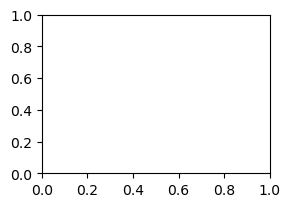

In [27]:
""" --- Integration test ---
 Author: Fuad Godzhaev
 Integration of multiple functions we have so far and testing if they work together
 The step-by-step process is as follows:
 1) Pre-processing: denoising, rotation, contrast adjustments
 2) Text-detection: segmentation of areas containing text
 3) Character recognition: breaking down highlited text region into individual characters for recognition

 TODO:
 -Check for colored/grey images; implement different behaviour
 -More robust edges and contour detection
 -Check for the image needing rotation (i.e. img3)
"""

import cv2
import numpy as np
from matplotlib import pyplot as plt


def pre_processing(img):
    # Applying denoising filter
    dst = cv2.fastNlMeansDenoising(img, None, 1, 7, 21)

    # Equalization
    clahe = cv2.createCLAHE(clipLimit=5)
    clahe_img = clahe.apply(dst).astype(np.uint8)
    
    # Compute Laplacian to highlight edges (foreground strokes)
    laplacian = cv2.Laplacian(clahe_img, cv2.CV_64F)
    laplacian = cv2.convertScaleAbs(laplacian)

    # Subtract Laplacian from blurred image to suppress background
    subtracted = cv2.subtract(clahe_img, laplacian)
    
    return(text_detection(subtracted))

def text_detection(img):
    # Apply global threshold (Otsu)
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological cleanup (remove small noise and fill gaps)
    kernel = np.ones((3,3), np.uint8)
    #cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

    return(cleaned)

def character_recognition(img):
    pass



# 1. Load image (replace with your handwritten image)
img1 = cv2.cvtColor(cv2.imread("data/samples/Handwritten_note.png"), cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(cv2.imread("data/samples/Handwritten_2025-09-18_110153.png"), cv2.COLOR_BGR2RGB)
img3 = cv2.cvtColor(cv2.imread("data/samples/Handwritten_2025-09-18_110153_2.png"), cv2.COLOR_BGR2RGB)
gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
gray3 = cv2.cvtColor(img3, cv2.COLOR_RGB2GRAY)

fig = plt.figure(figsize=(10, 7))
rows = 3
columns = 3

fig.add_subplot(rows, columns, 1) 
plt.imshow(pre_processing(gray1), 'gray')
plt.title("processed_image 1")

fig.add_subplot(rows, columns, 2) 
plt.imshow(pre_processing(gray2), 'gray')
plt.title("processed_image 2")

fig.add_subplot(rows, columns, 3) 
plt.imshow(pre_processing(gray3), 'gray')
plt.title("processed_image 3")

fig.add_subplot(rows, columns, 4) 
plt.imshow(img1)
plt.title("UNprocessed_image 1")

fig.add_subplot(rows, columns, 5) 
plt.imshow(img2)
plt.title("UNprocessed_image 2")

fig.add_subplot(rows, columns, 6) 
plt.imshow(img3)
plt.title("UNprocessed_image 3")

#cv2.imshow("img1", pre_processing(gray1))
#cv2.imshow("img2", pre_processing(gray2))
#cv2.imshow("img3", pre_processing(gray3))

cv2.waitKey(0)
cv2.destroyAllWindows()

plt.tight_layout()
plt.show()